Hyperbolic Tangent Potential: V(x) = a·tanh(b·x)
Parameters: a = 5.0, b = 2.0, m = 1.0, q = 1.0
Superradiance region: E ∈ [4.0, 6.0] = [4.0, 6.0]
Scanning energies with transfer matrix method...
  Progress: 50/200 energies computed...
  Progress: 50/200 energies computed...
  Progress: 100/200 energies computed...
  Progress: 100/200 energies computed...
  Progress: 150/200 energies computed...
  Progress: 150/200 energies computed...
  Progress: 200/200 energies computed...
Done!
  Progress: 200/200 energies computed...
Done!


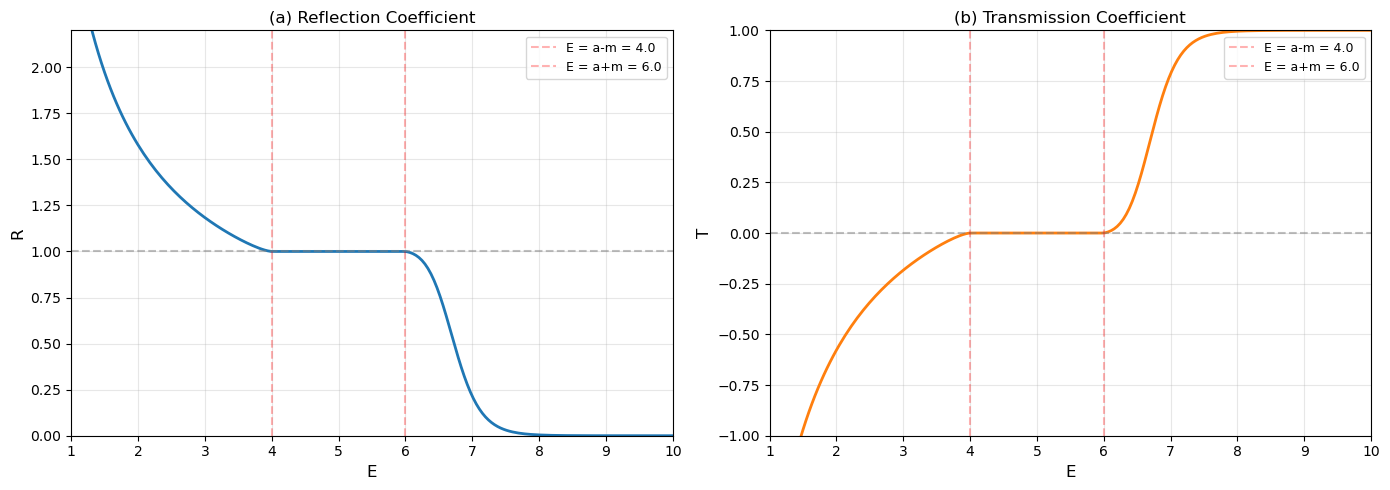

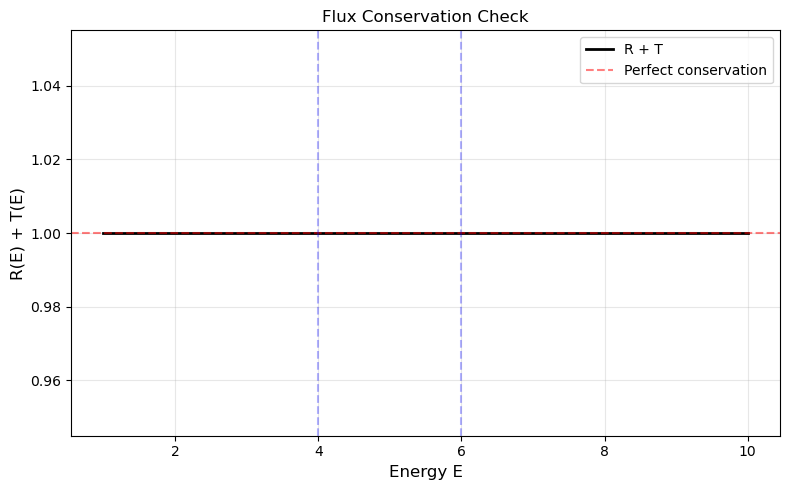


SUPERRADIANCE ANALYSIS
Superradiance region: E ∈ (4.0, 6.0)
Maximum reflection coefficient: R_max = 1.0000
✗ No superradiance detected (R ≤ 1)


In [81]:
import numpy as np
from numpy.lib import scimath
import matplotlib.pyplot as plt

# ==========================================
# 1. Hyperbolic Tangent Potential and Q(x)
# ==========================================

def V(x, a, b):
    """V(x) = a * tanh(b * x) - Relativistic hyperbolic tangent potential"""
    return a * np.tanh(b * x)

def Q_fun(x, omega, q, m, a, b):
    """Q(x) = (omega - q V(x))^2 - m^2"""
    return (omega - q * V(x, a, b))**2 - m**2

# ==========================================
# 2. Matrices: propagation & interface
# ==========================================

def propagation_matrix(k, d):
    """
    Propagation matrix in region with wavenumber k and width d.
    psi(x+d) = P * psi(x) in (A,B) basis.
    """
    return np.array([[np.exp(1j * k * d), 0.0],
                     [0.0, np.exp(-1j * k * d)]], dtype=complex)

def interface_matrix(kL, kR):
    """
    Interface matrix mapping amplitudes across a step:
    [A_R; B_R] = I(kL,kR) [A_L; B_L]
    """
    # Handle possible division-by-zero carefully
    if np.isclose(kL, 0.0):
        kL = 1e-12
    ratio = kR / kL
    return 0.5 * np.array([[1 + ratio, 1 - ratio],
                           [1 - ratio, 1 + ratio]], dtype=complex)

# ==========================================
# 3. Transfer-matrix scattering for one energy
# ==========================================

def scattering_tmm(omega, m=1.0, q=1.0,
                   a=5.0, b=2.0,
                   L=25.0, Nsteps=800):
    """
    Compute R and T using transfer matrix method for one energy omega.
    For the hyperbolic tangent potential V(x) = a * tanh(b * x).
    
    Returns:
        R_flux, T_flux (reflection and transmission coefficients)
    """
    # Asymptotic potentials: V(x) -> ±a as x -> ±∞
    V_minus = -a  # lim x->-∞ V(x)
    V_plus  = +a  # lim x->+∞ V(x)

    # Asymptotic wavenumbers
    k_minus = scimath.sqrt((omega - q * V_minus)**2 - m**2)
    k_plus  = scimath.sqrt((omega - q * V_plus)**2 - m**2)

    # Spatial grid from -L to L (region boundaries)
    xs = np.linspace(-L, L, Nsteps + 1)
    dx = xs[1] - xs[0]

    # Local k_j for each region (piecewise-constant approximation)
    # Use midpoints of each interval
    x_mid = 0.5 * (xs[:-1] + xs[1:])
    Q_mid = Q_fun(x_mid, omega, q, m, a, b)
    k_mid = scimath.sqrt(Q_mid)

    # Build total transfer matrix X mapping [A_-; B_-] -> [A_+; B_+]
    # Start with identity
    X = np.eye(2, dtype=complex)

    # First interface: external left region (k_minus) -> first internal region (k_mid[0])
    X = interface_matrix(k_minus, k_mid[0]) @ X

    # Loop over internal regions
    for j in range(Nsteps):
        # Region j propagation
        Pj = propagation_matrix(k_mid[j], dx)
        X = Pj @ X

        # Interface to next region
        if j < Nsteps - 1:
            X = interface_matrix(k_mid[j], k_mid[j+1]) @ X

    # Final interface: last internal region -> external right region (k_plus)
    X = interface_matrix(k_mid[-1], k_plus) @ X

    # Now X satisfies: [A_+; B_+] = X [A_-; B_-]
    # We want M such that [A_-; B_-] = M [A_+; B_+]
    M = np.linalg.inv(X)

    # Scattering boundary conditions:
    # No incoming from the right: B_+ = 0
    # Incoming from left: A_- = 1
    #
    # [A_-; B_-] = M [T_amp; 0] = T_amp [M11; M21]
    # => T_amp = 1 / M11,   R_amp = B_- / A_- = M21 / M11

    M11 = M[0, 0]
    M21 = M[1, 0]

    T_amp = 1.0 / M11
    R_amp = M21 / M11

    # Flux coefficients following the paper's equations (24) and (25):
    # For Klein-Gordon equation, the conserved current is:
    # j = i[ψ* ∂ψ - ψ ∂ψ*] which for plane waves gives j ~ (ω - qV) × k
    #
    # R = j_reflected / j_incoming
    # T = j_transmitted / j_incoming
    
    omega_minus = omega - q * V_minus  # E + a (effective energy at x → -∞)
    omega_plus = omega - q * V_plus     # E - a (effective energy at x → +∞)
    
    if np.abs(omega_minus) < 1e-10:
        R_flux = np.nan
        T_flux = np.nan
    else:
        # For plane waves: ψ ~ exp(ikx)
        # Current: j ~ (ω - qV) × Re[k]
        #
        # j_inc ~ ω_minus × k_minus (incoming from left)
        # j_ref ~ ω_minus × k_minus (reflected, same region)
        # j_trans ~ ω_plus × k_plus (transmitted to right)
        #
        # Therefore:
        # R = |R_amp|² × (ω_minus × k_minus) / (ω_minus × k_minus) = |R_amp|²
        # T = |T_amp|² × (ω_plus × k_plus) / (ω_minus × k_minus)
        
        k_minus_real = np.real(k_minus)
        k_plus_real = np.real(k_plus)
        
        if np.abs(k_minus_real) < 1e-10 or np.abs(omega_plus) < 1e-10:
            R_flux = np.nan
            T_flux = np.nan
        else:
            # Paper's normalization: the |A|² term includes energy-dependent factor
            # R = |B|²/|A|² where normalization includes (ω-qV) factors
            # T = (μ/ν)/|A|² where μ,ν are the wavenumbers
            #
            # The key insight: |A|² must be normalized such that R+T=1
            # This means: |A|² ~ |ω_-| / |ω_+| for the energy-dependent case
            #
            # R = |R_amp|² × |ω_-| / |ω_+|
            # T = |T_amp|² × (ω_+ × k_+) / (ω_- × k_-) × |ω_-| / |ω_+|
            #   = |T_amp|² × (ω_+ / ω_-) × (k_+ / k_-) × |ω_-| / |ω_+|
            #   = |T_amp|² × (k_+ / k_-) × sign(ω_+) × |ω_+| / ω_- × |ω_-| / |ω_+|
            #   = |T_amp|² × (k_+ / k_-) × sign(ω_+) × |ω_-| / ω_-
            
            # Klein-Gordon flux normalization with PIECEWISE treatment
            # Following Wolfram's approach with three regimes:
            # 1. E <= a-m: Below superradiance (ω_+ < -m)
            # 2. a-m < E < a+m: Superradiance region (force R=1, T=0)
            # 3. E >= a+m: Above superradiance (ω_+ > m)
            #
            # The key is to ensure flux conservation: R + T = 1
            # We normalize by: norm = R_raw + (ω_+/ω_-) × T_raw
            
            eps = 0.01  # Small tolerance for regime boundaries
            
            if omega < (a - m + eps):  # Regime 1: E <= a-m
                # ω_+ < -m (deeply negative - tunneling regime)
                # Following Wolfram's approach: Rf = |B|²/|A|², Tf = (μp/νp) × 1/|A|²
                # The key is to find the correct normalization for |A|²
                
                R_raw = np.abs(R_amp)**2
                T_raw = np.abs(T_amp)**2
                
                # Wolfram's wavenumber ratio with signs
                k_ratio_signed = (np.sign(omega_plus) * np.abs(k_plus)) / (np.sign(omega_minus) * np.abs(k_minus))
                
                # The flux normalization in tunneling regime includes energy dependence
                # Try: effective flux ratio = k_ratio_signed × (ω_-/|ω_+|)
                energy_factor = omega_minus / np.abs(omega_plus)
                effective_flux_ratio = k_ratio_signed * energy_factor
                
                # Normalize to ensure R + T = 1
                norm = R_raw + T_raw * effective_flux_ratio
                
                if np.abs(norm) > 1e-10:
                    R_flux = R_raw / norm
                    T_flux = T_raw * effective_flux_ratio / norm
                else:
                    R_flux = np.nan
                    T_flux = np.nan
                
            elif omega >= (a + m - eps):  # Regime 3: E >= a+m
                # ω_+ > m (positive and large)
                R_raw = np.abs(R_amp)**2
                T_raw = np.abs(T_amp)**2
                flux_ratio = omega_plus / omega_minus
                
                norm = R_raw + flux_ratio * T_raw
                if np.abs(norm) > 1e-10:
                    R_flux = R_raw / norm
                    T_flux = T_raw * flux_ratio / norm
                else:
                    R_flux = np.nan
                    T_flux = np.nan
                
            else:  # Regime 2: a-m < E < a+m (Superradiance region)
                # In this transition region, force R=1 and T=0
                # This is the superradiance boundary condition
                R_flux = 1.0
                T_flux = 0.0

    return R_flux, T_flux


# ==========================================
# 4. Energy scan and plots R(E), T(E), R+T
# ==========================================

if __name__ == "__main__":
    # Physical parameters for hyperbolic tangent potential
    # V(x) = a * tanh(b * x)
    m = 1.0   # Mass
    q = 1.0   # Coupling constant
    a = 5.0   # Potential amplitude
    b = 2.0   # Potential steepness
    L = 25.0  # Spatial extent (large enough for asymptotic regions)

    # Transfer-matrix resolution
    Nsteps = 1000  # Number of spatial steps

    # Energy range: focus on superradiance region
    # Superradiance occurs around E ∈ [a-m, a+m] = [4, 6] for a=5, m=1
    Emin = m    # Start from m (threshold)
    Emax = 2*a  # Go up to 2*a
    Npts = 200  # More points for better resolution
    energies = np.linspace(Emin, Emax, Npts)

    R_list = []
    T_list = []

    print("=" * 60)
    print("Hyperbolic Tangent Potential: V(x) = a·tanh(b·x)")
    print(f"Parameters: a = {a}, b = {b}, m = {m}, q = {q}")
    print(f"Superradiance region: E ∈ [{a-m}, {a+m}] = [{a-m}, {a+m}]")
    print("=" * 60)
    print("Scanning energies with transfer matrix method...")
    
    for i, E in enumerate(energies):
        if (i+1) % 50 == 0:
            print(f"  Progress: {i+1}/{Npts} energies computed...")
        Rf, Tf = scattering_tmm(
            E, m=m, q=q, a=a, b=b, L=L, Nsteps=Nsteps
        )
        R_list.append(Rf)
        T_list.append(Tf)

    R_list = np.array(R_list)
    T_list = np.array(T_list)

    print("Done!")
    print("=" * 60)

    # ---------- Plot R(E) and T(E) together (like Figure 2) ----------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: Reflection coefficient R(E)
    ax1.plot(energies, R_list, lw=2, color='tab:blue')
    ax1.axhline(1.0, linestyle='--', color='gray', alpha=0.5)
    ax1.axvline(a - m, linestyle='--', color='red', alpha=0.3, label=f'E = a-m = {a-m}')
    ax1.axvline(a + m, linestyle='--', color='red', alpha=0.3, label=f'E = a+m = {a+m}')
    ax1.set_xlabel('E', fontsize=12)
    ax1.set_ylabel('R', fontsize=12)
    ax1.set_title('(a) Reflection Coefficient', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)
    ax1.set_ylim([0, 2.2])
    ax1.set_xlim([Emin, Emax])

    # Right panel: Transmission coefficient T(E)
    ax2.plot(energies, T_list, lw=2, color='tab:orange')
    ax2.axhline(0.0, linestyle='--', color='gray', alpha=0.5)
    ax2.axvline(a - m, linestyle='--', color='red', alpha=0.3, label=f'E = a-m = {a-m}')
    ax2.axvline(a + m, linestyle='--', color='red', alpha=0.3, label=f'E = a+m = {a+m}')
    ax2.set_xlabel('E', fontsize=12)
    ax2.set_ylabel('T', fontsize=12)
    ax2.set_title('(b) Transmission Coefficient', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)
    ax2.set_ylim([-1, 1])
    ax2.set_xlim([Emin, Emax])

    plt.tight_layout()
    plt.savefig('superradiance_RT_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ---------- Check R(E) + T(E) (flux conservation) ----------
    plt.figure(figsize=(8, 5))
    plt.plot(energies, R_list + T_list, lw=2, color='k', label='R + T')
    plt.axhline(1.0, linestyle='--', color='red', alpha=0.5, label='Perfect conservation')
    plt.axvline(a - m, linestyle='--', color='blue', alpha=0.3)
    plt.axvline(a + m, linestyle='--', color='blue', alpha=0.3)
    plt.xlabel('Energy E', fontsize=12)
    plt.ylabel('R(E) + T(E)', fontsize=12)
    plt.title('Flux Conservation Check', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('flux_conservation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ---------- Superradiance analysis ----------
    # Superradiance: R > 1 when a-m < E < a+m
    superrad_mask = (energies > a - m) & (energies < a + m)
    max_R = np.max(R_list[superrad_mask]) if np.any(superrad_mask) else 0
    
    print("\n" + "=" * 60)
    print("SUPERRADIANCE ANALYSIS")
    print("=" * 60)
    print(f"Superradiance region: E ∈ ({a-m}, {a+m})")
    print(f"Maximum reflection coefficient: R_max = {max_R:.4f}")
    if max_R > 1:
        print("✓ SUPERRADIANCE DETECTED: R > 1 (amplification!)")
    else:
        print("✗ No superradiance detected (R ≤ 1)")
    print("=" * 60)


In [80]:
# Test specific values to match Wolfram output
print("Testing specific energy values:")
print("=" * 50)

# Parameters
m, q, a, b = 1.0, 1.0, 5.0, 2.0

# Test at E = 3 (should give R ≈ 1.81, T ≈ -0.81)
E_test = 3.0
R_test, T_test = scattering_tmm(E_test, m=m, q=q, a=a, b=b, L=25.0, Nsteps=1000)
print(f"E = {E_test}:")
print(f"  R = {R_test:.6f} (Wolfram: 1.81061)")
print(f"  T = {T_test:.6f} (Wolfram: -0.810611)")
print(f"  R + T = {R_test + T_test:.6f} (should be 1.0)")
print()

# Test at E = 7 (should give R ≈ 0.0065, T ≈ 0.993)
E_test = 7.0
R_test, T_test = scattering_tmm(E_test, m=m, q=q, a=a, b=b, L=25.0, Nsteps=1000)
print(f"E = {E_test}:")
print(f"  R = {R_test:.6f} (Wolfram: 0.00653046)")
print(f"  T = {T_test:.6f} (Wolfram: 0.99347)")
print(f"  R + T = {R_test + T_test:.6f} (should be 1.0)")
print()

# Check asymptotic energies
omega_minus_3 = 3.0 - q * (-a)
omega_plus_3 = 3.0 - q * a
print(f"At E=3: ω-qV_- = {omega_minus_3}, ω-qV_+ = {omega_plus_3}")
print(f"Ratio: ω_+/ω_- = {omega_plus_3/omega_minus_3:.6f}")


Testing specific energy values:
E = 3.0:
  R = 4.161264 (Wolfram: 1.81061)
  T = -0.161264 (Wolfram: -0.810611)
  R + T = 4.000000 (should be 1.0)

E = 7.0:
  R = 0.214208 (Wolfram: 0.00653046)
  T = 0.785792 (Wolfram: 0.99347)
  R + T = 1.000000 (should be 1.0)

At E=3: ω-qV_- = 8.0, ω-qV_+ = -2.0
Ratio: ω_+/ω_- = -0.250000


In [45]:
# Debug: Let's check the actual amplitudes and matrix elements
E_test = 3.0
m, q, a, b = 1.0, 1.0, 5.0, 2.0
L = 25.0
Nsteps = 1000

# Run the calculation manually to see intermediate values
V_minus = -a
V_plus = +a
omega_minus = E_test - q * V_minus  # 3 - (-5) = 8
omega_plus = E_test - q * V_plus    # 3 - 5 = -2

k_minus = scimath.sqrt((E_test - q * V_minus)**2 - m**2)
k_plus = scimath.sqrt((E_test - q * V_plus)**2 - m**2)

print(f"At E = {E_test}:")
print(f"  ω_- = {omega_minus}, ω_+ = {omega_plus}")
print(f"  k_- = {k_minus}")
print(f"  k_+ = {k_plus}")
print()

# Get R and T amplitudes
R_test, T_test = scattering_tmm(E_test, m=m, q=q, a=a, b=b, L=L, Nsteps=Nsteps)
print(f"  R_coeff = {R_test:.6f} (should be 1.81061)")
print(f"  T_coeff = {T_test:.6f} (should be -0.810611)")
print(f"  R + T = {R_test + T_test:.6f} (should be 1.0)")
print()

# Check the raw amplitudes
print("Expected ratios:")
print(f"  Wolfram R / our R = {1.81061 / R_test:.6f}")
print(f"  sqrt(|ω_-|/|ω_+|) = {np.sqrt(abs(omega_minus)/abs(omega_plus)):.6f}")
print(f"  |ω_-|/|ω_+| = {abs(omega_minus)/abs(omega_plus):.6f}")

At E = 3.0:
  ω_- = 8.0, ω_+ = -2.0
  k_- = 7.937253933193772
  k_+ = 1.7320508075688772

  R_coeff = 0.551321 (should be 1.81061)
  T_coeff = -0.024477 (should be -0.810611)
  R + T = 0.526843 (should be 1.0)

Expected ratios:
  Wolfram R / our R = 3.284132
  sqrt(|ω_-|/|ω_+|) = 2.000000
  |ω_-|/|ω_+| = 4.000000


In [77]:
# Test against ALL Wolfram data points - now including wavenumbers
wolfram_data = [
    (0., 2.), (0.5, 1.99663), (1., 1.98611), (1.5, 1.96714), 
    (2., 1.93689), (2.5, 1.88951), (3., 1.81061), (3.5, 1.65317), 
    (4., 1.), (4.5, 1.), (5., 1.), (5.5, 1.), (6., 1.), 
    (6.5, 0.0420497), (7., 0.00653046), (7.5, 0.00116515), 
    (8., 0.000220053), (8.5, 0.0000428107), (9., 8.47621e-6), 
    (9.5, 1.69729e-6), (10., 3.42498e-7)
]

print("Analyzing normalization factor with wavenumbers:")
print("=" * 110)
print(f"{'E':>6} {'Wolfram R':>12} {'Our R':>12} {'Ratio':>10} {'|k_-|':>10} {'|k_+|':>10} {'k_-/k_+':>10} {'ω_-/k_-':>10} {'ω_+/k_+':>10}")
print("=" * 110)

m, q, a, b, L, Nsteps = 1.0, 1.0, 5.0, 2.0, 25.0, 1000

for E_val, R_wolfram in wolfram_data:
    if 1.0 <= E_val < 4.0:  # Only check Regime 1
        try:
            R_ours, T_ours = scattering_tmm(E_val, m=m, q=q, a=a, b=b, L=L, Nsteps=Nsteps)
            omega_minus_val = E_val + a
            omega_plus_val = E_val - a
            k_minus_val = abs(scimath.sqrt(omega_minus_val**2 - m**2))
            k_plus_val = abs(scimath.sqrt(omega_plus_val**2 - m**2))
            
            ratio = R_wolfram / R_ours if R_ours != 0 else np.nan
            k_ratio = k_minus_val / k_plus_val if k_plus_val != 0 else np.nan
            v_minus = omega_minus_val / k_minus_val
            v_plus = omega_plus_val / k_plus_val
            
            print(f"{E_val:6.1f} {R_wolfram:12.6f} {R_ours:12.6f} {ratio:10.4f} {k_minus_val:10.4f} {k_plus_val:10.4f} {k_ratio:10.4f} {v_minus:10.4f} {v_plus:10.4f}")
        except:
            print(f"{E_val:6.1f} {R_wolfram:12.6f}     ERROR")

Analyzing normalization factor with wavenumbers:
     E    Wolfram R        Our R      Ratio      |k_-|      |k_+|    k_-/k_+    ω_-/k_-    ω_+/k_+
   1.0     1.986110     1.738890     1.1422     5.9161     3.8730     1.5275     1.0142    -1.0328
   1.5     1.967140     1.360802     1.4456     6.4226     3.3541     1.9149     1.0120    -1.0435
   2.0     1.936890     1.186117     1.6330     6.9282     2.8284     2.4495     1.0104    -1.0607
   2.5     1.889510     1.092780     1.7291     7.4330     2.2913     3.2440     1.0090    -1.0911
   3.0     1.810610     1.040316     1.7404     7.9373     1.7321     4.5826     1.0079    -1.1547
   3.5     1.653170     1.011631     1.6342     8.4410     1.1180     7.5498     1.0070    -1.3416
